--- Starting Execution with Raw Rates K Estimation ---
--- Extracting and Imputing Pure IT Infrastructure Metrics (Official Broad Categories) ---

[ Imputation Summary by Industry ]
Imputation_Type
Official Broader Category (2-Digit)    164
Official Broader Category (3-Digit)     79
Original Data (Official)                17
Official Broader Category (4-Digit)     13
Global Average (Computed)                4
Name: count, dtype: int64
--- Normalizing DII Scores for Baseline Positioning ---
[All] Mean K: 0.342526, Std K: 0.072957
[SME] Mean K: 0.342016, Std K: 0.069984
[Large_Company] Mean K: 0.408887, Std K: 0.224882

LIST OF IMPUTED INDUSTRIES (Snapshot)
    NAICS                               NAICS_TITLE  \
0  113300                                   Logging   
1  113300                                   Logging   
2  113300                                   Logging   
3  115100    Support Activities for Crop Production   
4  115100    Support Activities for Crop Production   
5  115

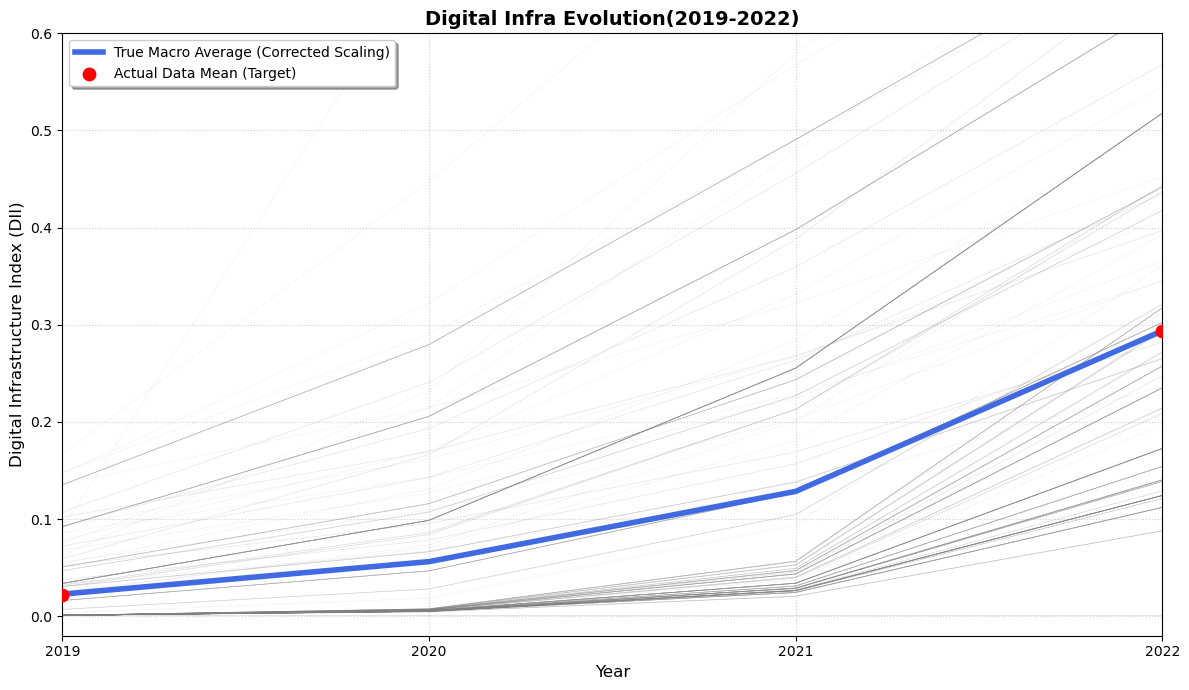

In [1]:
# ===DII speed computed by Only raw cloud usage and raw special software usage average include firm number===

'''
Computes the "d" parameter (diffusion speed) for digital infrastructure. 
It compares adoption rates of cloud and software  between 2019 and 2022 
using NSF data and calculates the industry-specificadoption odds-ratio.
'''

import pandas as pd
import numpy as np
import warnings
import re
import os
from sklearn.preprocessing import StandardScaler

# =============================================================================
# PART 0: PARAMETERS SETTINGS 
# =============================================================================
# Ignore specific warnings from openpyxl and general pandas warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
warnings.filterwarnings('ignore')

# Create output directory if it doesn't exist
OUTPUT_DIR = 'output_dii_speed_pure_infra'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Directory '{OUTPUT_DIR}' created.")

# Mathematical Bounding: Prevents DII from being exactly 0 or 1 to avoid 
MINIMUM_DII_VALUE = 1e-9
MAXIMUM_DII_VALUE = 1.0 - MINIMUM_DII_VALUE 

# Timeframe: We are measuring adoption speed between 2019 and 2022 (3 years).
YEAR_START_BASELINE = 2019
YEAR_END_TARGET = 2022
TIME_DELTA_YEARS = YEAR_END_TARGET - YEAR_START_BASELINE

# Weighting Logic: Cloud usage: specialized software = 6:4
WEIGHT_CLOUD = 0.6
WEIGHT_SOFTWARE = 0.4
REPLICATION =  1000

# Labels for data segmentation
LABEL_SIZE_SME = 'SME'
LABEL_SIZE_LARGE = 'Large_Company'
LABEL_SIZE_ALL = 'All'

# --- File Paths Configuration ---
# BLS: Used for the master list of 6-digit NAICS industries.
# SUSB: Used for firm counts to weight the industry averages.
# NSF Tables: Primary source for Cloud/Software adoption percentages and the performance gap between small and large firms.
FILE_PATH_BLS_STAFFING = 'bls_staffing_pattern_exclude_multipler1.csv'
FILE_PATH_SUSB_WEIGHTS = 'Employment_and_Payroll_by_industry_by_companysize_susb_united_states_only.csv'

FILE_PATH_NSF_CLOUD_2022 = 'nsf25303-tab076.xlsx'
FILE_PATH_NSF_SOFTWARE_2022 = 'nsf25303-tab078.xlsx'
FILE_PATH_NSF_CLOUD_GAP_2022 = 'nsf25303-tab077.xlsx'
FILE_PATH_NSF_SOFTWARE_GAP_2022 = 'nsf25303-tab079.xlsx'

FILE_PATH_NSF_CLOUD_2019 = 'nsf22315-tab086.xlsx'
FILE_PATH_NSF_SOFTWARE_2019 = 'nsf22315-tab088.xlsx'
FILE_PATH_NSF_CLOUD_GAP_2019 = 'nsf22315-tab087.xlsx'
FILE_PATH_NSF_SOFTWARE_GAP_2019 = 'nsf22315-tab089.xlsx'

# =============================================================================
# PART 1: HELPER FUNCTIONS
# =============================================================================
def standardize_naics_code_to_6_digits(code_input):
    """
    Cleans NAICS code inputs. It removes non-numeric characters and 
    right-pads the string with zeros to ensure every code is exactly 6 digits.
    Example: '541' becomes '541000'.'44-45' becomes '444500'
    """
    if pd.isna(code_input): return ""
    numeric_s = re.sub(r'[^0-9]', '', str(code_input).split('.')[0])
    return numeric_s.ljust(6, '0')

def expand_naics_ranges(raw_string):
    """
    Parses complex NAICS range strings from NSF tables.
    Example input: '311-313, 315'
    Logic:
    1. Replaces various dash characters with a standard hyphen.
    2. Splits by comma to get individual items.
    3. If a hyphen exists, it calculates the range. 
       - Handles shared prefixes: '311-15' is interpreted as '311 to 315'.
    4. Returns a list of standardized 6-digit codes.
    """
    if pd.isna(raw_string): return []
    codes = []
    raw_string = str(raw_string).replace('–', '-').replace('—', '-').replace('−', '-')
    for p in raw_string.replace('other ', '').split(','):
        p = p.strip()
        if '-' in p:
            try:
                s, e = p.split('-')
                start_val, end_val = s.strip(), e.strip()
                if len(start_val) == len(end_val):
                    start_num, end_num = int(start_val), int(end_val)
                else:
                    prefix = start_val[:-len(end_val)] if len(start_val) > len(end_val) else ""
                    start_num, end_num = int(start_val), int(prefix + end_val)
                for i in range(start_num, end_num + 1): 
                    codes.append(standardize_naics_code_to_6_digits(str(i)))
            except: 
                codes.append(standardize_naics_code_to_6_digits(p))
        elif p: 
            codes.append(standardize_naics_code_to_6_digits(p))
    return codes

def build_dict(path, col):
    """
    Reads an NSF Excel file and creates a lookup dictionary where:
    Key: 6-digit NAICS code
    Value: Adoption rate (as a float, e.g., 0.45 for 45%)
    """
    d = {}
    # Skip header rows; column 1 contains the NAICS range, 'col' contains the data
    for _, r in pd.read_excel(path, skiprows=3, engine='openpyxl').iterrows():
        rate = pd.to_numeric(r.iloc[col], errors='coerce') * 0.01
        for c in expand_naics_ranges(r.iloc[1]): d[c] = rate
    return d

def get_national_gap_ratio(path, col_idx):
    """
    Determines the "Adoption Gap" between Large companies and SMEs at a national level.
    The ratio = (Weighted Avg Rate of Large Firms) / (Weighted Avg Rate of SMEs).
    """
    df = pd.read_excel(path, skiprows=3, engine='openpyxl')
    # Pre-defined row indices in NSF tables corresponding to specific size brackets
    s_idx, l_idx = [2,3,5,6,8,9,11],[12,13,14,15,16]  # SMEs (<500) vs Large (500+)
    # Calculate weighted averages (Firm count * rate) / Total firms
    s_sub = df.iloc[s_idx, [1, col_idx]].apply(pd.to_numeric, errors='coerce')
    l_sub = df.iloc[l_idx, [1, col_idx]].apply(pd.to_numeric, errors='coerce')
    return ((l_sub.iloc[:, 0]*l_sub.iloc[:, 1]).sum() / l_sub.iloc[:, 0].sum()) / \
           ((s_sub.iloc[:, 0]*s_sub.iloc[:, 1]).sum() / s_sub.iloc[:, 0].sum())

def calculate_k_from_raw_rates(d0, dt, t):
    """
    Calculates the 'd' coefficient (Diffusion Speed).
    Formula based on the logistic growth model:
    d = (1 / t) * ln( [DII(t) / (1 - DII(t)] / [DII(0) / (1 - DII(0)] )
    This represents the intrinsic rate of growth in technology adoption.
    """
    d0_c = max(0.001, min(0.999, d0))
    dt_c = max(0.001, min(0.999, dt))
    # Relative odds ratio of adoption at time t vs time 0
    ratio = (dt_c * (1.0 - d0_c)) / (d0_c * (1.0 - dt_c))
    if ratio <= 1.0: return 0.0001
    return (1.0 / t) * np.log(ratio)

# =============================================================================
# PART 2: DATA EXTRACTION AND HIERARCHICAL IMPUTATION
# =============================================================================
def extract_and_impute_infrastructure_rates(df_bls_base_naics):
    print("--- Extracting and Imputing Pure IT Infrastructure Metrics (Official Broad Categories) ---")
    """
    Fills in adoption data for every 6-digit NAICS industry.
    Hierarchical Search Logic:
    1. Look for the exact 6-digit code in NSF data.
    2. If missing, look for the 5-digit parent code (e.g., 541511 -> 541510).
    3. Continue up to 2-digits.
    4. If still missing, use the global industry average.
    """
    dict_c_2019 = build_dict(FILE_PATH_NSF_CLOUD_2019, 10)
    dict_s_2019 = build_dict(FILE_PATH_NSF_SOFTWARE_2019, 10)
    dict_c_2022 = build_dict(FILE_PATH_NSF_CLOUD_2022, 10)
    dict_s_2022 = build_dict(FILE_PATH_NSF_SOFTWARE_2022, 10)
    
    df_rates = df_bls_base_naics.copy()
    
    def get_rate_and_level(naics, source_dict):
        if pd.isna(naics): return np.nan, 'Missing'
        # Search from 6-digit down to 2-digit specificity
        for spec in range(6, 1, -1):
            key = str(naics)[:spec].ljust(6, '0')
            if key in source_dict:
                if spec >= 5: return source_dict[key], 'Original Data (Official)'
                else: return source_dict[key], f'Official Broader Category ({spec}-Digit)'
        return np.nan, 'Missing'

    # Process Cloud and Software for both years
    search_results = df_rates['NAICS'].apply(lambda x: get_rate_and_level(x, dict_c_2022))
    df_rates['c_2022'] = [res[0] for res in search_results]
    df_rates['Imputation_Type'] = [res[1] for res in search_results]
    
    df_rates['c_2019'] = df_rates['NAICS'].apply(lambda x: get_rate_and_level(x, dict_c_2019)[0])
    df_rates['s_2019'] = df_rates['NAICS'].apply(lambda x: get_rate_and_level(x, dict_s_2019)[0])
    df_rates['s_2022'] = df_rates['NAICS'].apply(lambda x: get_rate_and_level(x, dict_s_2022)[0])

    # Final cleanup: Apply global average for industries with zero data coverage
    for col in ['c_2019', 's_2019', 'c_2022', 's_2022']:
        global_mean = df_rates[col].mean()
        mask_missing = df_rates[col].isna()
        df_rates.loc[mask_missing, col] = global_mean
        df_rates.loc[mask_missing, 'Imputation_Type'] = 'Global Average (Computed)'

    print("\n[ Imputation Summary by Industry ]")
    print(df_rates['Imputation_Type'].value_counts())
    return df_rates

# =============================================================================
# PART 3: MAIN EXECUTION AND k ESTIMATION MODEL
# =============================================================================
def run_pure_infra_dynamic_k_estimation(df_bls_base_naics, df_susb_weights_master):
    """
    Combines adoption rates with industry weights (firm counts) and 
    calculates the DII and Speed coefficients for SME and Large segments.
    """
    df_base_rates = extract_and_impute_infrastructure_rates(df_bls_base_naics)

    # Retrieve national-level adoption gaps between Large and Small firms
    gap_c_2019 = get_national_gap_ratio(FILE_PATH_NSF_CLOUD_GAP_2019, 9)
    gap_s_2019 = get_national_gap_ratio(FILE_PATH_NSF_SOFTWARE_GAP_2019, 9)
    gap_c_2022 = get_national_gap_ratio(FILE_PATH_NSF_CLOUD_GAP_2022, 9)
    gap_s_2022 = get_national_gap_ratio(FILE_PATH_NSF_SOFTWARE_GAP_2022, 9)

    # Merge rates with SUSB weight data
    df_sim_ready = df_base_rates.merge(df_susb_weights_master, on='NAICS', how='left')
    df_sim_ready[['w_sme', 'w_large', 'wa_firms']] = df_sim_ready[['w_sme', 'w_large', 'wa_firms']].fillna(1000)
    
    records = []
    def decomp(avg, gap, share_l):
        """
        Algebraic Decomposition:
        Splits a single industry average (avg) into SME adoption (s) and Large adoption (l).
        Requires the ratio between them (gap) and the percentage of Large firms in the industry (share_l).
        """
        s = avg / ((1 - share_l) + (share_l * gap))
        return s, min(1.0, s * gap)

    for _, row in df_sim_ready.iterrows():
        # Calculate the share of Large companies in this specific industry
        ws, wl = row['w_sme'], row['w_large']
        total_firms = ws + wl
        firm_share_l = wl / total_firms if pd.notna(total_firms) and total_firms > 0 else 0.5

        # Decompose the overall industry averages into Small vs Large components
        cs_19, cl_19 = decomp(row['c_2019'], gap_c_2019, firm_share_l)
        ss_19, sl_19 = decomp(row['s_2019'], gap_s_2019, firm_share_l)
        cs_22, cl_22 = decomp(row['c_2022'], gap_c_2022, firm_share_l)
        ss_22, sl_22 = decomp(row['s_2022'], gap_s_2022, firm_share_l)

       
        # Generate results for each size category (Total, SME, Large)
        for sz_cat, c19, s19, c22, s22, firms_count in [
            (LABEL_SIZE_ALL, row['c_2019'], row['s_2019'], row['c_2022'], row['s_2022'], row['wa_firms']),
            (LABEL_SIZE_SME, cs_19, ss_19, cs_22, ss_22, row['w_sme']),
            (LABEL_SIZE_LARGE, cl_19, sl_19, cl_22, sl_22, row['w_large'])
        ]:
            k_cloud = calculate_k_from_raw_rates(c19, c22, TIME_DELTA_YEARS)
            k_soft = calculate_k_from_raw_rates(s19, s22, TIME_DELTA_YEARS)
            final_k = (k_cloud + k_soft) / 2.0

            records.append({
                'NAICS': row['NAICS'], 'NAICS_TITLE': row['NAICS_TITLE'], 'Company_Size': sz_cat,
                'c_raw_2019': c19, 's_raw_2019': s19, 'c_raw_2022': c22, 's_raw_2022': s22,
                'k_cloud': k_cloud, 'k_soft': k_soft, 'diffusion_speed_k': final_k,
                'Imputation_Type': row['Imputation_Type'],
                'Number_of_Firms': firms_count 
            })
        
    df_k_results = pd.DataFrame(records)

    #  Fill any remaining missing values (NaN) in the 'Number_of_Firms' column with a default value of 1000.
    df_k_results['Number_of_Firms'] = df_k_results['Number_of_Firms'].fillna(1000)


    # --- Normalization Logic ---
    # Converts adoption rates into a standardized 0.0 to 1.0 DII score.
    # Uses StandardScaler to find relative positioning (Z-scores) of industries.
    print("--- Normalizing DII Scores for Baseline Positioning ---")    
    scaler = StandardScaler()
    base_2022_all = df_k_results[df_k_results['Company_Size'] == LABEL_SIZE_ALL][['c_raw_2022', 's_raw_2022']]
    scaler.fit(base_2022_all)
    
    def get_dii_z(c, s):
        # Apply normalization and calculate weighted average of the Z-scores
        zv = scaler.transform([[c, s]])[0]
        return zv[0]*WEIGHT_CLOUD + zv[1]*WEIGHT_SOFTWARE

    df_k_results['z_2019'] = df_k_results.apply(lambda r: get_dii_z(r['c_raw_2019'], r['s_raw_2019']), axis=1)
    df_k_results['z_2022'] = df_k_results.apply(lambda r: get_dii_z(r['c_raw_2022'], r['s_raw_2022']), axis=1)

    # Scale the Z-scores so the 2022 "All Industry" data maps to the 0-1 range
    z22_all = df_k_results[df_k_results['Company_Size'] == LABEL_SIZE_ALL]['z_2022']
    z_min, z_max = z22_all.min(), z22_all.max()
    z_range = z_max - z_min

    # Apply Min-Max scaling
    df_k_results[f'DII_{YEAR_START_BASELINE}'] = df_k_results['z_2019'].apply(lambda x: max(MINIMUM_DII_VALUE, min(MAXIMUM_DII_VALUE, (x - z_min)/z_range)))
    df_k_results[f'DII_{YEAR_END_TARGET}'] = df_k_results['z_2022'].apply(lambda x: max(MINIMUM_DII_VALUE, min(MAXIMUM_DII_VALUE, (x - z_min)/z_range)))

    mc_params = {}
    for sz in [LABEL_SIZE_ALL, LABEL_SIZE_SME, LABEL_SIZE_LARGE]:
        subset_k = df_k_results[df_k_results['Company_Size'] == sz]['diffusion_speed_k']
        mc_params[sz] = {'mu': subset_k.mean(), 'std': subset_k.std()}
        print(f"[{sz}] Mean K: {mc_params[sz]['mu']:.6f}, Std K: {mc_params[sz]['std']:.6f}")

    return df_k_results, mc_params

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == '__main__':
    print("--- Starting Execution with Raw Rates K Estimation ---")
     # 1. Initialize master NAICS list from BLS data
    df_bls_raw = pd.read_csv(FILE_PATH_BLS_STAFFING, dtype={'NAICS': str})
    df_bls_raw['NAICS'] = df_bls_raw['NAICS'].str.strip()
    df_bls_clean = df_bls_raw[(df_bls_raw['NAICS'].str.len() == 6) & (df_bls_raw['NAICS'] != '000001')].copy()
    df_bls_base_naics = df_bls_clean[['NAICS', 'NAICS_TITLE']].drop_duplicates().copy()

    # 2. Process SUSB Weights (Firm counts by size category)
    df_susb_w = pd.read_csv(FILE_PATH_SUSB_WEIGHTS, dtype=str)
    df_susb_w.columns = df_susb_w.columns.str.strip()
    df_susb_w['NAICS_clean'] = df_susb_w['NAICS'].apply(standardize_naics_code_to_6_digits)
    df_susb_w['f_n'] = pd.to_numeric(df_susb_w['Firms'].str.replace(',', ''), errors='coerce')

    # Grouping logic for size codes in SUSB (08 = SMEs, 09 = Large, 01 = Total)
    ws_df = df_susb_w[df_susb_w['Enterprise Size'].str.contains('08:', na=False)].groupby('NAICS_clean')['f_n'].sum().reset_index().rename(columns={'NAICS_clean':'NAICS', 'f_n':'w_sme'})
    wl_df = df_susb_w[df_susb_w['Enterprise Size'].str.contains('09:', na=False)].groupby('NAICS_clean')['f_n'].sum().reset_index().rename(columns={'NAICS_clean':'NAICS', 'f_n':'w_large'})
    wa_df = df_susb_w[df_susb_w['Enterprise Size'].str.contains('01:', na=False)].groupby('NAICS_clean')['f_n'].sum().reset_index().rename(columns={'NAICS_clean':'NAICS', 'f_n':'wa_firms'})
    
    df_weights = pd.merge(ws_df, wl_df, on='NAICS', how='outer')
    df_weights = pd.merge(df_weights, wa_df, on='NAICS', how='outer')
    
    # 3. Manual Weight Imputation Rules
    # Some NAICS codes are missing in SUSB. We map them to their parent or similar industry code to ensure they have weights for decomposition.
    ref_weights = df_weights.set_index('NAICS')
    def get_ref_values(code):
        if code in ref_weights.index: 
            return ref_weights.loc[code, ['w_sme', 'w_large', 'wa_firms']]
        # if the number of firms is missing value, it is imputed by 1000
        return pd.Series([1000, 1000, 1000], index=['w_sme', 'w_large', 'wa_firms'])

    # Map missing detailed industries to their parent/related industry counts
    impute_rules = [
        # Retail Trade: Use weights from the broad '44-45' sector (444500) to fill missing sub-sectors like furniture, electronics, and clothing stores.
        ('444500', ['449100','449200','455000','456110','457100','457200','458100','458200','458300','459110','459200','459300','459900','4590A1','4450A1']),
        # Transportation & Warehousing: Use weights from the '48-49' sector (484900) to fill missing data for Rail Transportation (482100) and Postal Service (491100).
        ('484900', ['482100', '491100']),
        # Information: Use the broad '51' sector (510000) weights to fill missing digital publishing, broadcasting, and web search portal industries.
        ('510000', ['513110', '513200', '516110', '516120', '516200', '519200']),
        # Finance & Insurance: Use the broad '52' sector (520000) weights to fill missing data for specific pension and health/welfare funds (525100).
        ('520000', ['525100'])
    ]

    for code_target, replacement_codes in impute_rules:
        val = get_ref_values(code_target)
        if not val.isna().any():
            df_weights.loc[df_weights['NAICS'].isin(replacement_codes), ['w_sme', 'w_large', 'wa_firms']] = val.values

    # Handle special NAICS codes containing 'A' using a 3-digit prefix fallback
    a_mask = df_weights['w_sme'].isna() & df_weights['NAICS'].str.contains('A', na=False)
    for idx, row in df_weights[a_mask].iterrows():
        val_prefix = get_ref_values(row['NAICS'][:3].ljust(6, '0'))
        if not val_prefix.isna().any():
            df_weights.loc[df_weights.index == idx, ['w_sme', 'w_large', 'wa_firms']] = val_prefix.values

    # 4. Run the calculation pipeline
    df_k_results, monte_carlo_params = run_pure_infra_dynamic_k_estimation(df_bls_base_naics, df_weights)
    
     # 5. Output results
    print("\n" + "="*80)
    print("LIST OF IMPUTED INDUSTRIES (Snapshot)")
    print("="*80)
    print(df_k_results[df_k_results['Imputation_Type'].str.contains('Official Broader|Global', na=False)][['NAICS', 'NAICS_TITLE', 'Imputation_Type']].head(10))

    output_path = os.path.join(OUTPUT_DIR, "DX_Adoption_Speed_K_6_4.csv")
    df_k_results.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\nSUCCESS: Results saved to {output_path}")

'''
Calculates and visualizes the logistic growth trajectories of the Digital Infrastructure Index 
for various industries between 2019 and 2022, while also computing and plotting the overall macro-average 
to verify it perfectly aligns with the actual measured data points.
'''
import matplotlib.pyplot as plt
import numpy as np

# =============================================================
# 1. Set Simulation Range
# =============================================================
start_sim_year = 2019
end_sim_year = 2022  # Timeframe strictly covering the actual measured period
years = np.arange(start_sim_year, end_sim_year + 1)
t_values = years - start_sim_year

# Extract a copy of the specific subset of data to plot (filtering by company size)
df_plot = df_k_results[df_k_results['Company_Size'] == LABEL_SIZE_ALL].copy()

# =============================================================
# 2. Calculate Trajectories for Each Industry 
#    (Adjusting the growth rate 'k' for visualization)
# =============================================================
all_trajectories = []

for _, row in df_plot.iterrows():
    # Retrieve the initial and target DII (Digital Infrastructure Index)
    d0 = row[f'DII_{YEAR_START_BASELINE}']
    dt = row[f'DII_{YEAR_END_TARGET}']
    
    # Guard to prevent calculation errors (e.g., division by zero or log(0))
    # Bounds DII values strictly between 0.001 and 0.999
    d0 = max(0.001, min(0.999, d0))
    dt = max(0.001, min(0.999, dt))
    
    # solve the logistic equation to find the exact growth rate (k) needed to move the DII
    # from d0 to dt over a 3-year period.
    # This guarantees each industry's line passes exactly through its actual 2019 and 2022 values.
    ratio = (dt * (1.0 - d0)) / (d0 * (1.0 - dt))
    if ratio > 1.0:
        # 3.0 represents the time span (2022 - 2019 = 3 years)
        k_visual = (1.0 / 3.0) * np.log(ratio)
    else:
        # Fallback to a near-zero growth rate for non-growing/stagnant cases
        k_visual = 0.0001
        
     # Calculate the logistic growth trajectory for the current industry over t_values (0 to 3)
    traj = [1 / (1 + ((1 - d0) / d0) * np.exp(-k_visual * t)) for t in t_values]
    all_trajectories.append(traj)

all_trajectories = np.array(all_trajectories)

# Calculate the macro average trajectory by averaging across all industries per year
macro_average_trajectory = np.mean(all_trajectories, axis=0)

# =============================================================
# 3. Plotting
# =============================================================
plt.figure(figsize=(12, 7))

# --- A. Trend for each individual industry (thin, semi-transparent lines) ---
for i in range(len(all_trajectories)):
    plt.plot(years, all_trajectories[i], color='gray', alpha=0.1, lw=0.5)

# --- B. Correct macro average trend (thick blue line) ---
plt.plot(years, macro_average_trajectory, color='royalblue', lw=4, 
         label=f'True Macro Average (Corrected Scaling)')

# --- C. Graph styling and decorations ---
plt.title('Digital Infra Evolution(2019-2022)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Digital Infrastructure Index (DII)', fontsize=12)
plt.ylim(-0.02, 0.6) 
plt.xlim(start_sim_year, end_sim_year)
plt.xticks(years)

# Calculate and plot the mean points of the actual measured values for visual verification
avg_d0_actual = df_plot[f'DII_{YEAR_START_BASELINE}'].mean()
avg_dt_actual = df_plot[f'DII_{YEAR_END_TARGET}'].mean()
plt.scatter([2019, 2022], [avg_d0_actual, avg_dt_actual], 
            color='red', s=80, zorder=5, label='Actual Data Mean (Target)')

# Add a dotted grid and a legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()
